# 05 · 真实数据准备、PPO 训练与基线比较

本 notebook 可独立运行：准备（或复用 04 的）真实数据快照，训练一个小型 PPO，再在相同测试日期上比较 PPO、alpha 等权与 robust top50。默认 4,096 步仅用于理解流程与工程检查。

In [1]:
from pathlib import Path
from dataclasses import asdict
import hashlib
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src/res/rl_experimental").is_dir()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# 项目导入必须放在设置 repo_root 之后，支持从 notebooks 子目录运行。
from src.res.rl_experimental.data import PanelData, date_split  # noqa: E402
from src.res.rl_experimental.real_data import RealDataConfig, prepare_real_data  # noqa: E402

print("Python:", sys.executable)
print("Project:", repo_root)
# 在 notebook 的内核选择器中选择项目 .venv/bin/python。


Python: /Users/mengkjin/workspace/learndl/.venv/bin/python
Project: /Users/mengkjin/workspace/learndl


## 准备真实数据

在项目主环境中依次运行，无需独立 RL 环境。以下示例读取本机已落库的 `pred@gru_day_V1`，默认先用 2025 年 1–2 月进行短实验；它不是新训练的 alpha，也尚未确认历史预测是否样本外。

04、05 的默认配置和输出位置相同。首次运行会导出数据，随后复用通过配置、文件指纹和数据契约检查的快照。修改源数据后需要主动重建；复用快照不会自动同步数据库。缺失日期会报错，不会自动换用其他 alpha。调整日期前应确认本机有回看期及最后决策日的下一交易日行情。


In [2]:
ALPHA_SPEC = "pred@gru_day_V1"  # 改用其他 alpha 时显式修改这里
START_DATE = 20250102
END_DATE = 20250228  # 决策日期；另需下一交易日行情及起点之前的特征回看数据
ALPHA_SAMPLE_STATUS = "unknown"  # 确认历史预测为样本外后才改为 "out-of-sample"
REBUILD_SNAPSHOT = False  # True 会重新读取数据库并覆盖本配置的导出快照

if not ALPHA_SPEC.strip():
    raise ValueError("请填写 alpha，例如 pred@gru_day_V1")
snapshot_name = f"{ALPHA_SPEC.replace('@', '_')}_{START_DATE}_{END_DATE}"
SNAPSHOT_DIR = repo_root / "results/rl_experimental/snapshots" / snapshot_name
data_config = RealDataConfig(
    alpha=ALPHA_SPEC,
    start=START_DATE,
    end=END_DATE,
    output=SNAPSHOT_DIR,
    alpha_direction=1,
    alpha_lag=0,
    max_alpha_staleness=0,  # 每日严格匹配；低频信号须显式放宽
    min_listing_days=63,
    alpha_sample_status=ALPHA_SAMPLE_STATUS,
)
data_config.validate()
display(asdict(data_config))


{'alpha': 'pred@gru_day_V1',
 'start': 20250102,
 'end': 20250228,
 'output': PosixPath('/Users/mengkjin/workspace/learndl/results/rl_experimental/snapshots/pred_gru_day_V1_20250102_20250228'),
 'alpha_direction': 1,
 'alpha_lag': 0,
 'max_alpha_staleness': 0,
 'min_listing_days': 63,
 'alpha_sample_status': 'unknown'}

In [3]:
# 此 dry-run 检查 alpha 覆盖、证券数量和预计数组大小，不写文件。
# 行情、涨跌停、风格和历史信息的完整检查在下一单元正式导出时完成。
audit = prepare_real_data(data_config, dry_run=True)["audit"]
display(audit)
print(f"Estimated panel arrays: {audit['estimated_bytes'] / 1024**2:.1f} MiB")
print("准备时 DataFrame、中间数组和训练副本还会额外占用内存。")


{'schema_version': 2,
 'requested_dates': [20250102, 20250228],
 'decision_count': 36,
 'stock_count': 5028,
 'estimated_bytes': 19367856,
 'alpha': {'expression': 'pred@gru_day_V1',
  'database_source': 'model_prediction',
  'database_key': 'gru_day_V1',
  'column': 'gru_day_V1',
  'direction': 1,
  'lag': 0,
  'max_staleness': 0,
  'sample_status': 'unknown',
  'source_date_range': [20250102, 20250228]}}

Estimated panel arrays: 18.5 MiB
准备时 DataFrame、中间数组和训练副本还会额外占用内存。


In [4]:
required_files = ["panel.npz", "manifest.json", "quality_report.json"]
existing = [(SNAPSHOT_DIR / name).is_file() for name in required_files]
expected_config = {**asdict(data_config), "output": str(SNAPSHOT_DIR)}

if REBUILD_SNAPSHOT or not any(existing):
    prepared = prepare_real_data(data_config)
    print("Exported:", prepared["panel"])
elif not all(existing):
    raise ValueError("快照文件不完整；检查输出目录后设置 REBUILD_SNAPSHOT=True 重新导出")
else:
    cached_manifest = json.loads((SNAPSHOT_DIR / "manifest.json").read_text(encoding="utf-8"))
    if cached_manifest["config"] != expected_config:
        raise ValueError("快照配置不匹配；请使用新目录或设置 REBUILD_SNAPSHOT=True")
    print("Reusing frozen snapshot:", SNAPSHOT_DIR)

manifest = json.loads((SNAPSHOT_DIR / "manifest.json").read_text(encoding="utf-8"))
quality = json.loads((SNAPSHOT_DIR / "quality_report.json").read_text(encoding="utf-8"))
with (SNAPSHOT_DIR / "panel.npz").open("rb") as handle:
    actual_sha256 = hashlib.file_digest(handle, "sha256").hexdigest()
if actual_sha256 != manifest["panel_sha256"]:
    raise ValueError("panel.npz 指纹不匹配；请重新导出快照")
panel = PanelData.load_npz(SNAPSHOT_DIR / "panel.npz")
if panel.contract() != manifest["panel_contract"]:
    raise ValueError("panel 与清单中的数据契约不匹配")
display(quality)
display(manifest["default_time_splits"])
print("Research status:", manifest["research_status"])


Reusing frozen snapshot: /Users/mengkjin/workspace/learndl/results/rl_experimental/snapshots/pred_gru_day_V1_20250102_20250228


{'investable_per_day': {'min': 4886, 'median': 4892.0, 'max': 4899},
 'alpha_coverage': 0.9902987713250243,
 'feature_missing_cells': {'ret_1d': 0,
  'ret_5d': 0,
  'ret_20d': 0,
  'volatility_20d': 0,
  'turnover_20d': 51,
  'amount_20d': 51,
  'size': 0,
  'beta': 0,
  'momentum': 0,
  'residual_volatility': 0,
  'liquidity': 0},
 'stale_valuation_cells': 317,
 'cannot_buy_cells': 462,
 'cannot_sell_cells': 213,
 'industry_missing_cells': 0}

{'train': {'indices': [0, 21],
  'decision_start': 20250102,
  'return_end': 20250210},
 'valid': {'indices': [21, 28],
  'decision_start': 20250210,
  'return_end': 20250219},
 'test': {'indices': [28, 36],
  'decision_start': 20250219,
  'return_end': 20250303}}

Research status: engineering experiment


## 训练设置

按时间顺序划分 60%/20%/20%，归一化只拟合训练段，验证和测试各自从现金开始。PPO 在训练段反复采样；验证净值决定最佳 checkpoint，测试段不参与模型选择。

默认使用 CPU，4090 机器可设 `DEVICE = "cuda"`。SB3 负责网络输入与参数的设备转移，行情环境仍在 CPU。每次运行训练单元会创建独立目录，避免覆盖已有模型。

In [5]:
from datetime import datetime, timezone
from src.res.rl_experimental.training import ExperimentConfig, train_experiment, evaluate_checkpoint
from src.res.rl_experimental.reward import RewardConfig

DEVICE = "cpu"
TOTAL_TIMESTEPS = 4096
SEED = 7
experiment_config = ExperimentConfig(
    candidate_count=100,
    max_holdings=50,
    max_weight=0.03,
    fee_rate=0.00035,
    reward=RewardConfig(
        turnover_penalty=0.0,
        downside_penalty=0.0,
        concentration_penalty=0.0,
    ),  # 三项为 0 时与原始 log-growth reward 完全一致
    selection_metric="nav",  # 可改为 discounted_reward
    n_envs=4,
    rollout_steps=128,  # 每轮 4 × 128 = 512 条经验；不是 128 天后的收益必定无效
    total_timesteps=TOTAL_TIMESTEPS,
    eval_freq=0,  # 每轮完整 PPO 更新后验证；正数表示环境步数间隔
    seed=SEED,
    device=DEVICE,
)
splits = date_split(panel, experiment_config.train_end_date, experiment_config.valid_end_date)
display(pd.DataFrame({
    name: {
        "transitions": end - start,
        "first_decision": int(panel.decision_dates[start]),
        "last_return_end": int(panel.return_end_dates[end - 1]),
    }
    for name, (start, end) in splits.items()
}).T)
display(asdict(experiment_config))


,transitions,first_decision,last_return_end
train,21,20250102,20250210
valid,7,20250210,20250219
test,8,20250219,20250303


{'candidate_count': 100,
 'max_holdings': 50,
 'max_weight': 0.03,
 'fee_rate': 0.00035,
 'selection_scale': 1.0,
 'reward_scale': 100.0,
 'n_envs': 4,
 'rollout_steps': 128,
 'batch_size': 128,
 'update_epochs': 4,
 'learning_rate': 0.0003,
 'gamma': 0.99,
 'gae_lambda': 0.95,
 'clip_range': 0.2,
 'hidden_dim': 64,
 'total_timesteps': 4096,
 'eval_freq': 0,
 'seed': 7,
 'device': 'cpu',
 'train_end_date': None,
 'valid_end_date': None}

## 训练时实时观察

先执行下面单元，再启动训练。默认查看所有实验目录，可以在 TensorBoard 中勾选具体 run 或比较不同 seed。页面可能需要等待首轮日志出现；若内嵌页面不可用，可在项目根目录终端运行：

```bash
.venv/bin/python -m tensorboard.main --logdir results/rl_experimental/runs --host localhost --port 6006
```

浏览器打开 http://localhost:6006。Scalars 查看 `train/`、`rollout/` 和 `validation/`，Images 查看最终 `test/comparison/curves`。验证相对等权收益反映组合效果，loss 的下降本身不代表投资表现改善。


In [ ]:
# 此服务独立于训练单元；重复执行时 TensorBoard 会复用相同参数的实例。
from IPython import get_ipython

tb_logdir = repo_root / "results/rl_experimental/runs"
tb_logdir.mkdir(parents=True, exist_ok=True)
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("load_ext", "tensorboard")
    ipython.run_line_magic("tensorboard", f'--logdir "{tb_logdir}" --host localhost --port 6006')
else:
    print("非 notebook 环境：请使用上面的终端命令启动 TensorBoard。")


In [8]:
run_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
RUN_DIR = repo_root / "results/rl_experimental/runs" / f"{snapshot_name}-seed{SEED}-{run_stamp}"
print("Training output:", RUN_DIR, flush=True)
metrics = train_experiment(panel, RUN_DIR, experiment_config)
print("Parameter change L2:", metrics["parameter_change_l2"])
display(metrics["timing"])
display(pd.DataFrame({
    name: metrics[name]
    for name in ["validation", "test", "alpha_equal_weight_baseline", "robust_top50_baseline"]
}).T)


Training output: /Users/mengkjin/workspace/learndl/results/rl_experimental/runs/pred_gru_day_V1_20250102_20250228-seed7-20261009T031949514188Z
Parameter change L2: 3.4155645867143485


{'training_seconds': 11.281535791931674,
 'rollout_seconds': 6.070196708897129,
 'update_seconds': 4.939113708096556,
 'validation_seconds': 0.13514137431047857,
 'steps_per_second': 363.07113459936687}

,total_return,annualized_volatility,max_drawdown,mean_turnover,final_nav,total_fees,mean_frozen_holdings,rejected_orders
validation,0.028212,0.297277,-0.016208,0.987441,1.028212,0.002426,0.000,0.0
test,0.112912,0.659926,-0.021575,1.102551,1.112912,0.003333,0.125,0.0
alpha_equal_weight_baseline,0.112694,0.628287,-0.019528,1.100905,1.112694,0.003322,0.125,0.0
robust_top50_baseline,0.120668,0.597261,-0.014693,0.316513,1.120668,0.000934,0.000,0.0


## Reward 分解

训练 reward 等于各分项之和。交易费用已经进入净值，因此 `turnover_penalty` 表达额外的低换手偏好。较大的下行或集中度惩罚可能让模型增加现金。自定义函数示例见 `src.res.rl_experimental.reward.example_drawdown_aware_reward`。

In [ ]:
updates = pd.read_csv(RUN_DIR / "update_history.csv")
reward_columns = [column for column in updates if column.startswith("rollout/reward_component/")]
if reward_columns:
    ax = updates.plot(x="environment_steps", y=reward_columns, marker=".", figsize=(12, 5))
    ax.set_title("Mean scaled reward contribution per PPO rollout")
    ax.set_ylabel("Reward contribution")
    ax.grid(alpha=.2)
display(updates[["update", "environment_steps", "rollout/reward_mean", *reward_columns]])


## 每轮 PPO 更新曲线

一个点对应一批 rollout 完成全部 epoch/minibatch 优化后的指标，横轴是累计环境步数。第 0 轮仅验证未经训练的策略，不参与最佳 checkpoint 选择。`value_loss` 是 critic 拟合损失；`explained_variance` 使用本轮采样时的价值预测，不能解释为更新后模型已重新预测的分数。SB3 的 `train/loss` 是最后一个 minibatch 的损失，其他指标沿用 SB3 的聚合定义。

默认每轮验证，最终一轮必定记录。若提高 `eval_freq`，更新指标仍逐轮保存，但验证只在达到间隔后的完整更新结束时执行。


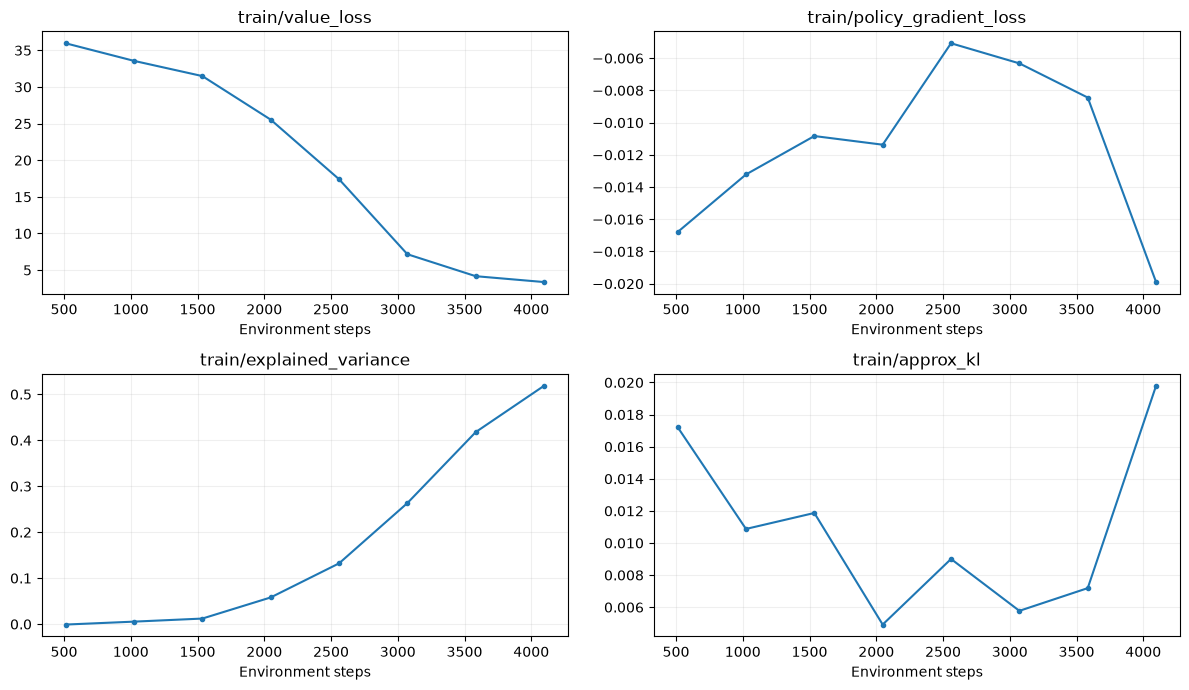

In [9]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

event_dirs = sorted({path.parent for path in (RUN_DIR / "tensorboard").rglob("events.out.tfevents.*")})
curve_frames = []
for log_dir in event_dirs:
    events = EventAccumulator(str(log_dir)).Reload()
    for tag in events.Tags()["scalars"]:
        curve_frames.extend(
            {"tag": tag, "step": event.step, "value": event.value}
            for event in events.Scalars(tag)
        )
training_curves = pd.DataFrame(curve_frames)
tags = ["train/value_loss", "train/policy_gradient_loss", "train/explained_variance", "train/approx_kl"]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, tag in zip(axes.flat, tags):
    if not training_curves.empty:
        one = training_curves[training_curves.tag == tag].sort_values("step")
        ax.plot(one.step, one.value, marker=".")
    ax.set_title(tag)
    ax.set_xlabel("Environment steps")
    ax.grid(alpha=.2)
plt.tight_layout()


,update,environment_steps,validated,time/rollout_seconds,time/update_seconds,time/validation_seconds
0,1,512,True,0.752785,0.701256,0.013562
1,2,1024,True,0.803348,0.668160,0.015375
2,3,1536,True,0.794099,0.604888,0.012845
3,4,2048,True,0.761409,0.595230,0.013318
4,5,2560,True,0.743413,0.595293,0.013651
5,6,3072,True,0.740281,0.597474,0.012996
6,7,3584,True,0.738031,0.593367,0.013138
7,8,4096,True,0.736830,0.583448,0.012978


Selected checkpoint update: 8


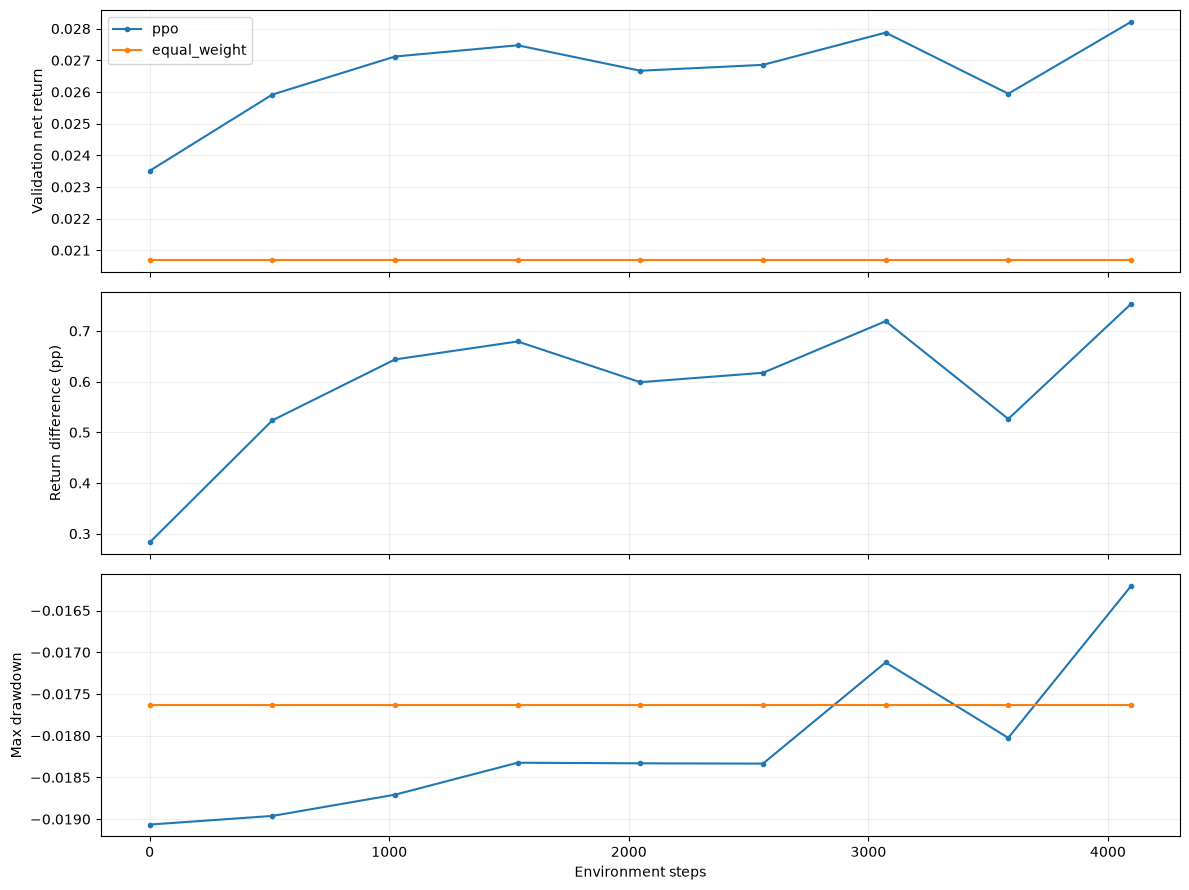

In [10]:
updates_path = RUN_DIR / "update_history.csv"
validation_path = RUN_DIR / "validation_updates.csv"
if updates_path.exists() and validation_path.exists():
    updates = pd.read_csv(updates_path)
    validation = pd.read_csv(validation_path)
    display(updates[["update", "environment_steps", "validated",
                     "time/rollout_seconds", "time/update_seconds", "time/validation_seconds"]])
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    for name in ["ppo", "equal_weight"]:
        axes[0].plot(validation.environment_steps, validation[f"validation/{name}/total_return"],
                     marker=".", label=name)
        axes[2].plot(validation.environment_steps, validation[f"validation/{name}/max_drawdown"],
                     marker=".", label=name)
    axes[1].plot(validation.environment_steps,
                 validation["validation/comparison/return_difference_pp"], marker=".")
    for ax, label in zip(axes, ["Validation net return", "Return difference (pp)", "Max drawdown"]):
        ax.set_ylabel(label)
        ax.grid(alpha=.2)
    axes[0].legend()
    axes[2].set_xlabel("Environment steps")
    plt.tight_layout()
    print("Selected checkpoint update:", metrics.get("best_update"))
else:
    print("旧运行没有逐轮 CSV；可继续查看已有 TensorBoard 日志和最终轨迹，末轮缺失记录无法补回。")


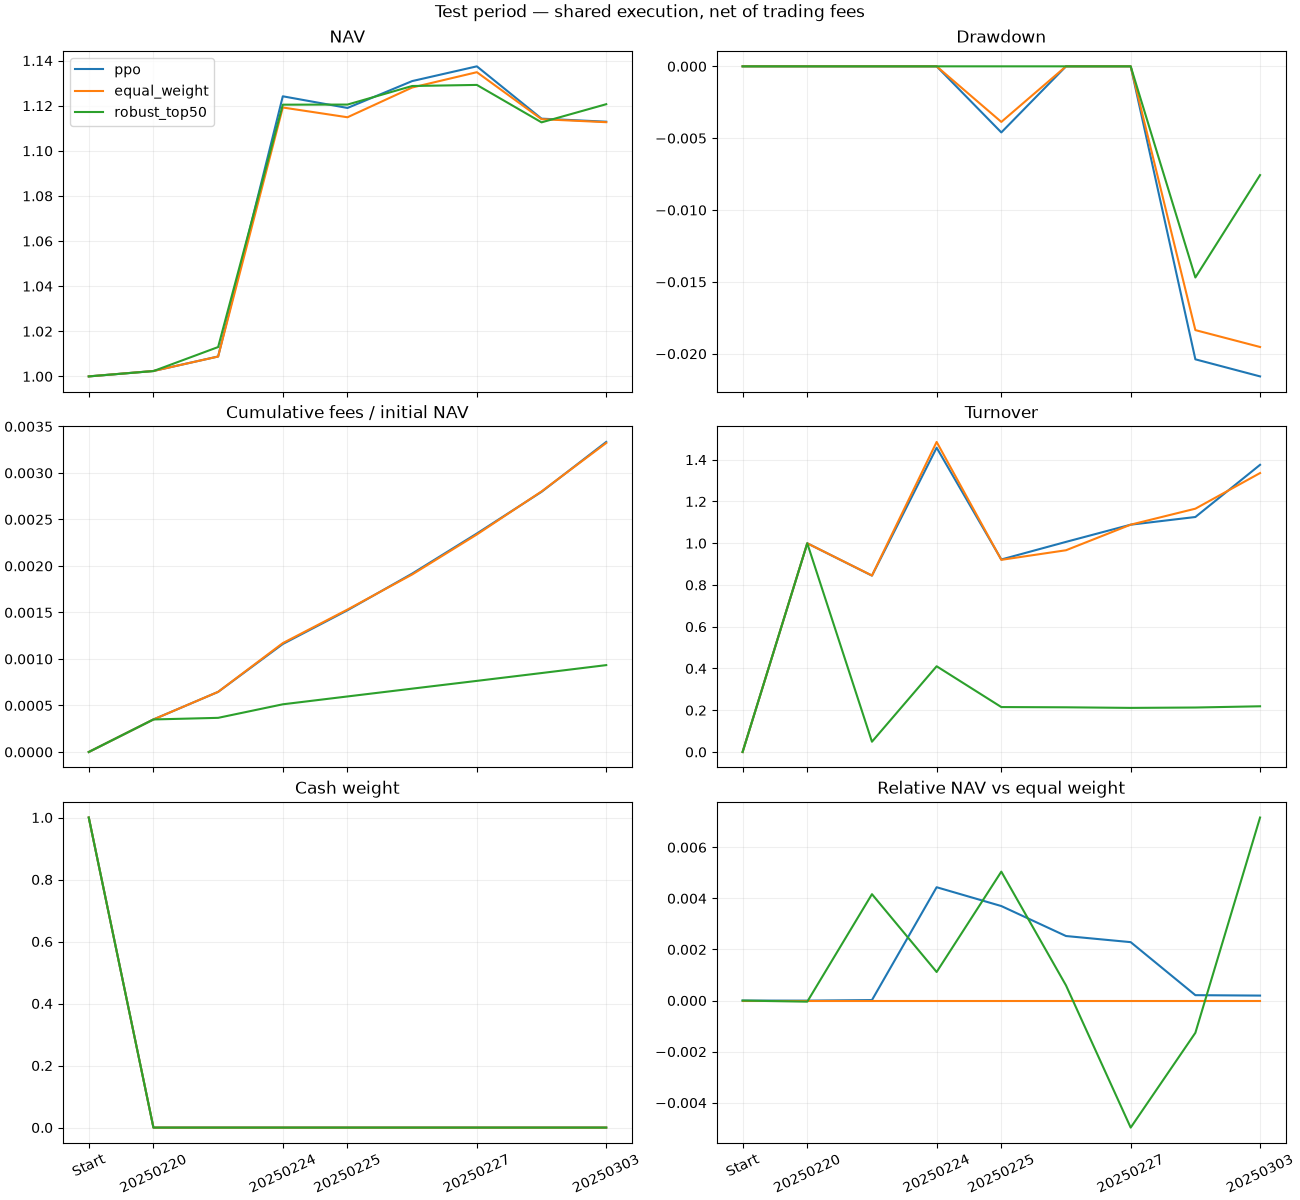

return_difference_pp          0.021776
relative_nav_return           0.000196
max_drawdown_difference_pp   -0.204650
volatility_difference_pp      3.163829
mean_turnover_difference      0.001646
total_fees_difference         0.000011
Name: PPO vs equal weight, dtype: float64

收益差单位为百分点；relative_nav_return = NAV_PPO / NAV_equal - 1。
费用以初始净值为单位；所有曲线已扣除实际交易费用。


In [11]:
from io import BytesIO
from IPython.display import Image
from src.res.rl_experimental.diagnostics import comparison_figure, compare_metrics

paths = {
    "ppo": RUN_DIR / "test_history.csv",
    "equal_weight": RUN_DIR / "alpha_equal_weight_history.csv",
    "robust_top50": RUN_DIR / "robust_top50_history.csv",
}
histories = {name: pd.read_csv(path) for name, path in paths.items() if path.exists()}
# 复用训练输出使用的同一绘图函数，检查决策及结算日期一致。
figure = comparison_figure({name: frame.to_dict("records") for name, frame in histories.items()})
buffer = BytesIO()
figure.savefig(buffer, format="png", dpi=100)
display(Image(data=buffer.getvalue()))
comparison = compare_metrics(metrics["test"], metrics["alpha_equal_weight_baseline"])
display(pd.Series(comparison, name="PPO vs equal weight"))
print("收益差单位为百分点；relative_nav_return = NAV_PPO / NAV_equal - 1。")
print("费用以初始净值为单位；所有曲线已扣除实际交易费用。")


In [12]:
diagnostics = []
for name, frame in histories.items():
    diagnostics.append({
        "strategy": name,
        "total_fee": frame.fee_estimate.sum(),
        "mean_holdings": frame.holdings.mean(),
        "mean_frozen": frame.get("frozen_holdings", pd.Series([0])).mean(),
        "rejected_buys": frame.get("rejected_buys", pd.Series([0])).sum(),
        "rejected_sells": frame.get("rejected_sells", pd.Series([0])).sum(),
    })
display(pd.DataFrame(diagnostics).set_index("strategy"))

# 重载最佳模型，复用保存的归一化参数，并检查确定性测试结果一致。
reloaded_metrics = evaluate_checkpoint(panel, RUN_DIR / "best_model.zip", RUN_DIR / "reload-check")
np.testing.assert_allclose(reloaded_metrics["final_nav"], metrics["test"]["final_nav"], rtol=1e-6)
print("Checkpoint reload passed:", RUN_DIR / "reload-check/deterministic_weights.csv")


,total_fee,mean_holdings,mean_frozen,rejected_buys,rejected_sells
strategy,,,,,
ppo,0.003333,50.0,0.125,0,0
equal_weight,0.003322,50.0,0.125,0,0
robust_top50,0.000934,50.0,0.000,0,0


Checkpoint reload passed: /Users/mengkjin/workspace/learndl/results/rl_experimental/runs/pred_gru_day_V1_20250102_20250228-seed7-20261009T031949514188Z/reload-check/deterministic_weights.csv


短区间、单种子和 4,096 步只验证流程，不足以判断 RL 优于现有策略。下一步先检查 alpha 的样本外来源，再扩展日期和训练步数；正式实验固定多组种子，测试集只做最终报告。训练完成后可以保留 `RUN_DIR`，直接读取其中的指标、轨迹和 TensorBoard 日志。